# 1. Data Preparation: Solar Resource Extraction from Global Solar Atlas

Extracts per-city solar resource baselines (PVOUT, GHI, DNI, TEMP) from Global Solar Atlas GeoTIFFs for the 48 BoM weather stations used in the Kaggle/rattle 'weatherAUS' dataset, using rasterio zonal-mean statistics over a 10km buffer around each station as a proxy for "the area covered by the city". See the project README for full methodology and assumptions.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

from solarout.config import CITY_COORDINATES_CSV, SOLAR_BASELINE_CSV
from solarout.raster_extract import ANNUAL_RASTERS, make_buffer_geom, zonal_mean

## City coordinates (geocoded via OSM Nominatim, manual overrides for ambiguous stations)

In [2]:
cities = pd.read_csv(CITY_COORDINATES_CSV)
print(len(cities), 'cities')
cities.head(10)

49 cities


,Location,lat,lon
0,Adelaide,-34.928181,138.599931
1,Albany,-35.024782,117.883608
2,Albury,-36.073773,146.913526
3,AliceSprings,-23.698000,133.880700
4,BadgerysCreek,-33.891100,150.744400
5,Ballarat,-37.562301,143.860565
6,Bendigo,-36.759018,144.282672
7,Brisbane,-27.468962,153.023501
8,Cairns,-16.920666,145.772185
9,Canberra,-35.297591,149.101268


## Global Solar Atlas raster: PVOUT (PV power output potential, kWh/kWp/day)

Annual long-term average daily total, EPSG:4326, ~1km resolution.

CRS: EPSG:4326
bounds: BoundingBox(left=112.0, bottom=-44.0, right=160.0, top=-9.0)
shape: (4200, 5760)


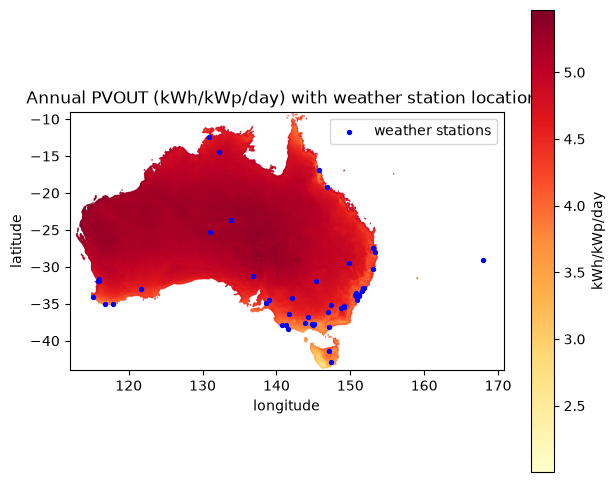

In [3]:
with rasterio.open(ANNUAL_RASTERS['PVOUT_annual_avg_daily']) as src:
    pvout = src.read(1)
    bounds = src.bounds
    crs = src.crs

print('CRS:', crs)
print('bounds:', bounds)
print('shape:', pvout.shape)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(np.where(np.isnan(pvout), np.nan, pvout), extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
               cmap='YlOrRd')
ax.scatter(cities['lon'], cities['lat'], c='blue', s=8, label='weather stations')
ax.set_title('Annual PVOUT (kWh/kWp/day) with weather station locations')
ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
fig.colorbar(im, label='kWh/kWp/day')
ax.legend()
plt.show()

## Zonal-mean extraction: 10km buffer around a station

We buffer each station point by 10km in a metric CRS (EPSG:3577, Australian Albers), reproject back to the raster's CRS, then average all valid pixels inside the buffer. This approximates "the area covered by the city" since authoritative city/town boundary polygons aren't uniformly available for all 48 stations (several are airports or small towns).

In [4]:
with rasterio.open(ANNUAL_RASTERS['PVOUT_annual_avg_daily']) as src:
    raster_crs = str(src.crs)

for city_name in ['Darwin', 'Hobart']:
    row = cities[cities['Location'] == city_name].iloc[0]
    geom = make_buffer_geom(row['lat'], row['lon'], raster_crs)
    val = zonal_mean(ANNUAL_RASTERS['PVOUT_annual_avg_daily'], geom)
    print(f'{city_name}: annual PVOUT = {val:.3f} kWh/kWp/day')

Darwin: annual PVOUT = 4.662 kWh/kWp/day
Hobart: annual PVOUT = 3.588 kWh/kWp/day


**Sanity check**: tropical Darwin should have meaningfully higher average solar resource than temperate Hobart -- confirmed above.

## Full extraction results (all 48 cities x 12 months)

In [5]:
baseline = pd.read_csv(SOLAR_BASELINE_CSV)
print(baseline.shape)
baseline.head()

(576, 7)


,Location,Month,PVOUT_avg_daily,PVOUT_annual_avg_daily,GHI_annual_avg_daily,DNI_annual_avg_daily,TEMP_annual_avg
0,Adelaide,1,5.639781,4.348316,4.785174,5.347703,16.334978
1,Adelaide,2,5.386417,4.348316,4.785174,5.347703,16.334978
2,Adelaide,3,4.873866,4.348316,4.785174,5.347703,16.334978
3,Adelaide,4,4.169172,4.348316,4.785174,5.347703,16.334978
4,Adelaide,5,3.105065,4.348316,4.785174,5.347703,16.334978


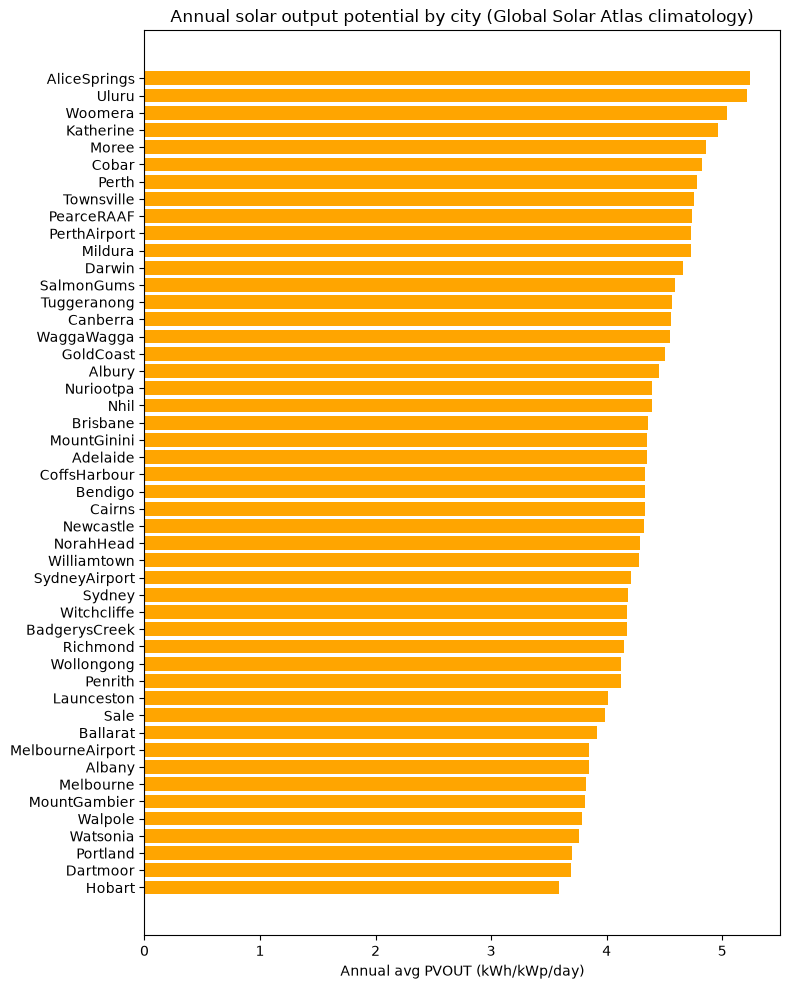

In [6]:
annual = baseline.drop_duplicates('Location').sort_values('PVOUT_annual_avg_daily', ascending=False)
fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(annual['Location'], annual['PVOUT_annual_avg_daily'], color='orange')
ax.set_xlabel('Annual avg PVOUT (kWh/kWp/day)')
ax.invert_yaxis()
ax.set_title('Annual solar output potential by city (Global Solar Atlas climatology)')
plt.tight_layout()
plt.show()

In [7]:
assert annual.set_index('Location').loc['Darwin', 'PVOUT_annual_avg_daily'] > \
       annual.set_index('Location').loc['Hobart', 'PVOUT_annual_avg_daily']
print('Sanity check passed: Darwin > Hobart')

Sanity check passed: Darwin > Hobart
